## Importing Libraries

In [39]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack,csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score

In [40]:
df=pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [42]:
df.shape

(17880, 18)

In [43]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [44]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [45]:
df.fraudulent.value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

## Basic EDA

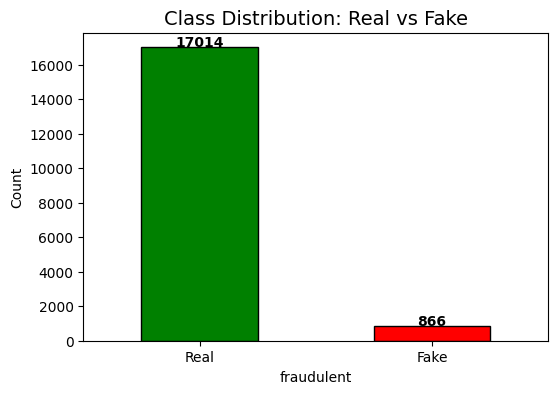

In [46]:
df["fraudulent"].value_counts().plot(kind="bar",color=["green","red"],edgecolor="black",figsize=(6,4))
plt.title("Class Distribution: Real vs Fake", fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Real', 'Fake'], rotation=0)
plt.ylabel('Count')
for i, v in enumerate(df['fraudulent'].value_counts().values):
    plt.text(i,v+30,str(v), ha="center", fontweight="bold")
plt.show()

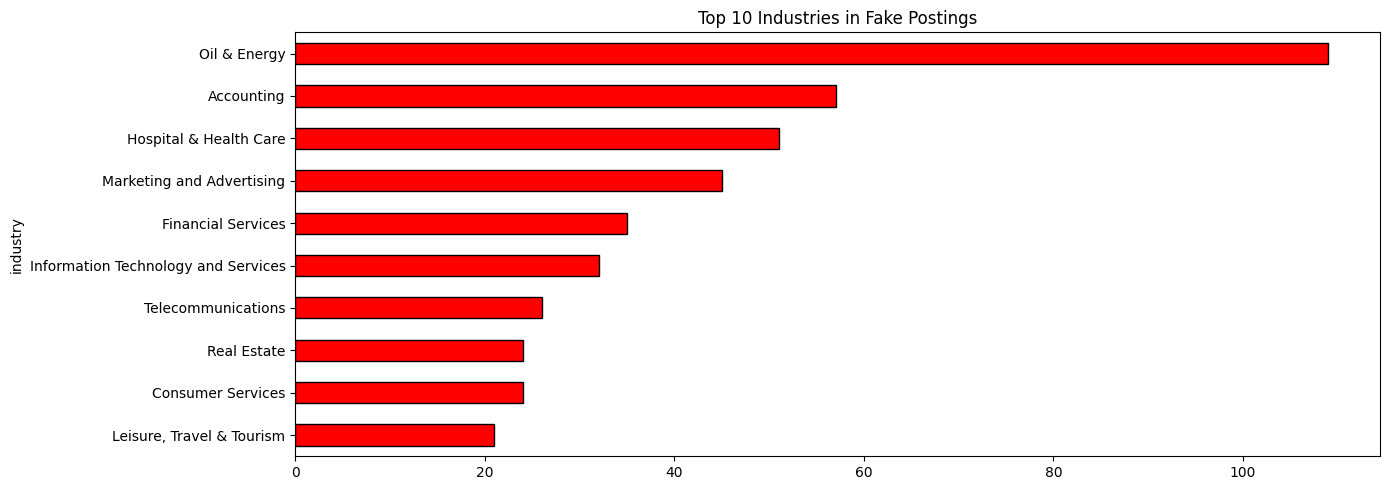

In [47]:
fraud_df=df[df["fraudulent"]==1]
fig, axes=plt.subplots(figsize=(14,5))
fraud_df["industry"].value_counts().head(10).plot(kind="barh",color="red",edgecolor="black",ax=axes)
axes.set_title("Top 10 Industries in Fake Postings")
axes.invert_yaxis()
plt.tight_layout()
plt.show()

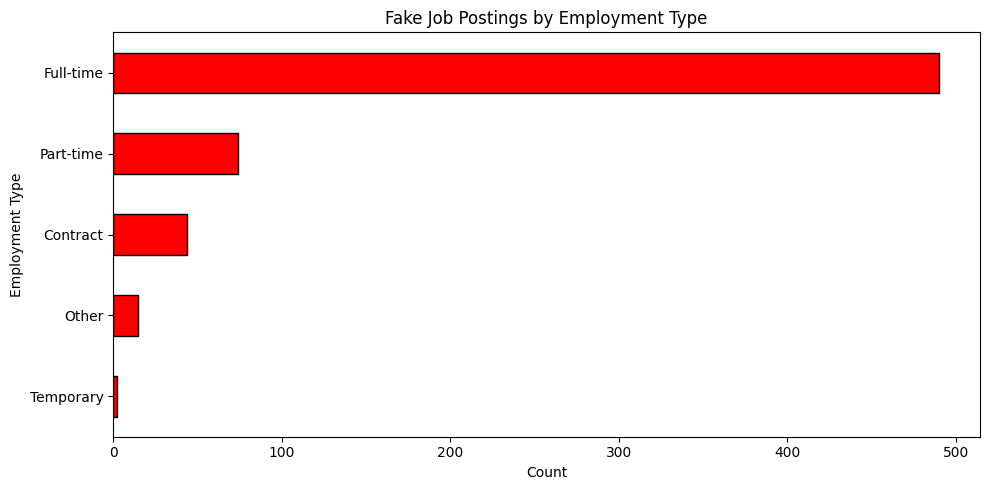

In [48]:
fraud_df = df[df["fraudulent"]==1]
fig, axes = plt.subplots(figsize=(10,5))
fraud_df["employment_type"].value_counts().head(10).plot(kind="barh",color="red",edgecolor="black",ax=axes)
axes.set_title("Fake Job Postings by Employment Type")
axes.set_xlabel("Count")
axes.set_ylabel("Employment Type")
axes.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
df=df.drop("job_id",axis=1)
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## Data preprocessing

In [12]:
df=df.drop(columns=["department","salary_range"])
df.head()


,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [13]:
df.dtypes

title                  object
location               object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

In [14]:
df.isnull().sum()

title                     0
location                346
company_profile        3308
description               1
requirements           2696
benefits               7212
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        3471
required_experience    7050
required_education     8105
industry               4903
function               6455
fraudulent                0
dtype: int64

In [15]:
text_cols=["title","description","requirements","company_profile","location","benefits"]
for i in text_cols:
    df[i]=df[i].fillna("").astype(str)

In [16]:
df.head(2)

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0


In [17]:
#Comnined Text

df["Text"]=df["title"]+" "+df["company_profile"]+" "+df["description"]+" "+df["requirements"]+" "+df["benefits"]
df["Text"]

0        Marketing Intern We're Food52, and we've creat...
1        Customer Service - Cloud Video Production 90 S...
2        Commissioning Machinery Assistant (CMA) Valor ...
3        Account Executive - Washington DC Our passion ...
4        Bill Review Manager SpotSource Solutions LLC i...
                               ...                        
17875    Account Director - Distribution  Vend is looki...
17876    Payroll Accountant WebLinc is the e-commerce p...
17877    Project Cost Control Staff Engineer - Cost Con...
17878    Graphic Designer  Nemsia Studios is looking fo...
17879    Web Application Developers Vend is looking for...
Name: Text, Length: 17880, dtype: object

In [18]:
cat_cols=["employment_type","required_experience","required_education","industry","function"]
for i in cat_cols:
    df[i]=df[i].replace("","unknown").fillna("unknown")

for i in cat_cols:
    print(df[i].unique())
    print()

['Other' 'Full-time' 'unknown' 'Part-time' 'Contract' 'Temporary']

['Internship' 'Not Applicable' 'unknown' 'Mid-Senior level' 'Associate'
 'Entry level' 'Executive' 'Director']

['unknown' "Bachelor's Degree" "Master's Degree"
 'High School or equivalent' 'Unspecified'
 'Some College Coursework Completed' 'Vocational' 'Certification'
 'Associate Degree' 'Professional' 'Doctorate'
 'Some High School Coursework' 'Vocational - Degree'
 'Vocational - HS Diploma']

['unknown' 'Marketing and Advertising' 'Computer Software'
 'Hospital & Health Care' 'Online Media'
 'Information Technology and Services' 'Financial Services'
 'Management Consulting' 'Events Services' 'Internet'
 'Facilities Services' 'Consumer Electronics' 'Telecommunications'
 'Consumer Services' 'Construction' 'Oil & Energy' 'Education Management'
 'Building Materials' 'Banking' 'Food & Beverages' 'Food Production'
 'Health, Wellness and Fitness' 'Insurance' 'E-Learning' 'Cosmetics'
 'Staffing and Recruiting' 'Venture Capi

In [19]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"@[A-Za-z0-9]+"," ",text)
    text=re.sub(r"#[A-Za-z0-9]+"," ",text)
    text=re.sub(r"https?://[A-Za-z0-9./]+"," ",text)
    text=re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["Text"]=df["Text"].apply(clean_text)

In [20]:
df["Text"].head(2)

0    marketing intern were food and weve created a ...
1    customer service  cloud video production  seco...
Name: Text, dtype: object

In [21]:
df.head(2)

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,Text
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,unknown,unknown,Marketing,0,marketing intern were food and weve created a ...
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,unknown,Marketing and Advertising,Customer Service,0,customer service cloud video production seco...


In [22]:
df=df.drop(columns=["title","location","company_profile","description","requirements","benefits"])

In [23]:
df.head(2)

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,Text
0,0,1,0,Other,Internship,unknown,unknown,Marketing,0,marketing intern were food and weve created a ...
1,0,1,0,Full-time,Not Applicable,unknown,Marketing and Advertising,Customer Service,0,customer service cloud video production seco...


In [24]:
df.function.value_counts()

function
unknown                   6455
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Writing/Editing            132
Art/Creative               132
Production                 116
Product Management         114
Quality Assurance          111
Advertising                 90
Business Analyst            84
Data Analyst                82
Public Relations            76
Manufacturing               74
General Business            68
Research                    50
Legal                       47
Strategy/Planning           46

In [25]:
x=df.drop("fraudulent",axis=1)
y=df["fraudulent"]

In [26]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [27]:
xtrain

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,Text
7530,0,1,0,Full-time,Entry level,Unspecified,Financial Services,Customer Service,contact center representatives tidewater finan...
129,0,1,0,Full-time,Entry level,High School or equivalent,Telecommunications,Customer Service,customer service associate novitex enterprise...
4640,0,1,1,Full-time,Mid-Senior level,unknown,Information Technology and Services,unknown,automated test analyst silverstripe cms amp fr...
402,0,1,0,Full-time,unknown,unknown,Building Materials,Sales,inside sales professionalomaha abc supply co i...
13218,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Marketing,content marketingseo manager meundies is a lif...
...,...,...,...,...,...,...,...,...,...
1841,0,1,1,Contract,Associate,Bachelor's Degree,Information Technology and Services,Public Relations,public relations manager happyfox is a young s...
11852,0,1,1,unknown,unknown,unknown,unknown,unknown,ios developer tizu is a free iphone app that a...
10870,0,1,0,Full-time,Entry level,High School or equivalent,Real Estate,unknown,database researcher with over investment prof...
565,0,1,0,Full-time,Entry level,High School or equivalent,Legal Services,Administrative,customer service associate novitex enterprise...


In [28]:
xtest

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,Text
16995,0,1,0,Full-time,unknown,unknown,Hospital & Health Care,Health Care Provider,excellent er rn opportunity available now our...
9357,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Project Management,scrum master website development project mana...
11561,0,1,0,Contract,Not Applicable,Unspecified,Information Technology and Services,Human Resources,hr assistant contract squiz is one of the wor...
1105,0,1,1,Full-time,Director,unknown,Telecommunications,Sales,regional sales director south africa upstreams...
1980,0,1,0,Full-time,Associate,Bachelor's Degree,Oil & Energy,unknown,petrophysicist valor services provides workfo...
...,...,...,...,...,...,...,...,...,...
7039,0,0,0,unknown,unknown,unknown,unknown,unknown,walkin for sales marketing specialist job d...
14472,0,1,0,unknown,unknown,unknown,unknown,unknown,home health cnaarco id critical nurse staffing...
14453,0,1,1,Full-time,unknown,unknown,Computer Software,Engineering,software engineer senior and junior we believe...
6296,0,1,1,unknown,unknown,unknown,unknown,unknown,work with us billguard is a personal finance s...


In [29]:
tfidf = TfidfVectorizer(max_features=5000,stop_words='english',ngram_range=(1, 2),min_df=2,max_df=0.95)

In [30]:
xtrain_text=tfidf.fit_transform(xtrain["Text"])
xtest_text=tfidf.transform(xtest["Text"])

In [31]:
oe=OneHotEncoder(handle_unknown="ignore")
xtrain_cat=oe.fit_transform(xtrain[cat_cols])
xtest_cat=oe.transform(xtest[cat_cols])

In [32]:
num_cols=["telecommuting","has_company_logo","has_questions"]
xtrain_num=csr_matrix(xtrain[num_cols].values)
xtest_num=csr_matrix(xtest[num_cols].values)

In [33]:
fxtrain=hstack([xtrain_text,xtrain_cat,xtrain_num]).tocsr()
fxtest=hstack([xtest_text,xtest_cat,xtest_num]).tocsr()

In [34]:
fxtrain.shape

(14304, 5199)

In [35]:
fxtest.shape

(3576, 5199)

## Cross Validation

#### model.score

In [36]:
Fold=StratifiedKFold(n_splits=5)

def get_score(model,xtrain,xtest,ytrain,ytest):
    model.fit(xtrain,ytrain)
    return model.score(xtest,ytest)



log_score=[]
rf_score=[]
lsvc_score=[]
dt_score=[]
knn_score=[]
ad_score=[]
gb_score=[]
xgb_score=[]

for train,test in Fold.split(fxtrain,ytrain):
    xtrain_fld,xtest_fld=fxtrain[train],fxtrain[test]
    ytrain_fld,ytest_fld=ytrain.iloc[train],ytrain.iloc[test]
    

    log_score.append(get_score(LogisticRegression(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    rf_score.append(get_score(RandomForestClassifier(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    lsvc_score.append(get_score(LinearSVC(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    dt_score.append(get_score(DecisionTreeClassifier(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    knn_score.append(get_score(KNeighborsClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    ad_score.append(get_score(AdaBoostClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    gb_score.append(get_score(GradientBoostingClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    xgb_score.append(get_score(XGBClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    


print("LogisticRegression",log_score)
print("RandomForestClassifier",rf_score)
print("LinearSVC",lsvc_score)
print("DecisionTreeClassifier",dt_score)
print("KNN",knn_score)
print("AdaBoostClassifier",ad_score)
print("GradientBoostingClassifier",gb_score)
print("XGBClassifier",xgb_score)

LogisticRegression [0.9545613421880461, 0.9545613421880461, 0.9563089828731213, 0.9601537923802866, 0.9576923076923077]
RandomForestClassifier [0.9772806710940231, 0.9772806710940231, 0.976232086682978, 0.975882558545963, 0.9762237762237762]
LinearSVC [0.9776301992310381, 0.9783292555050681, 0.9797273680531283, 0.9804264243271583, 0.9793706293706294]
DecisionTreeClassifier [0.9535127577770011, 0.9622509612023767, 0.965396714435512, 0.9626004893393918, 0.9608391608391609]
KNN [0.9751835022719328, 0.9772806710940231, 0.9776301992310381, 0.9706396364907375, 0.9755244755244755]
AdaBoostClassifier [0.9584061516952115, 0.9552603984620762, 0.9598042642432716, 0.9612023767913317, 0.9611888111888112]
GradientBoostingClassifier [0.9772806710940231, 0.9734358615868577, 0.9737853897238727, 0.9741349178608878, 0.9776223776223776]
XGBClassifier [0.9814750087382035, 0.9814750087382035, 0.9797273680531283, 0.9818245368752184, 0.9818181818181818]


In [37]:
print("LogisticRegression",np.mean(log_score))
print("RandomForestClassifier",np.mean(rf_score))
print("LinearSVC",np.mean(lsvc_score))
print("DecisionTreeClassifier",np.mean(dt_score))
print("KNN",np.mean(knn_score))
print("AdaBoostClassifier",np.mean(ad_score))
print("GradientBoostingClassifier",np.mean(gb_score))
print("XGBClassifier",np.mean(xgb_score))

LogisticRegression 0.9566555534643616
RandomForestClassifier 0.9765799527281527
LinearSVC 0.9790967752974045
DecisionTreeClassifier 0.9609200167186887
KNN 0.9752516969224414
AdaBoostClassifier 0.9591724004761405
GradientBoostingClassifier 0.9752518435776036
XGBClassifier 0.9812640208445871


### F1 Score

In [38]:
Fold=StratifiedKFold(n_splits=5)

def get_score1(model,xtrain,xtest,ytrain,ytest):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    return f1_score(ytest,ypred)



log_score1=[]
rf_score1=[]
lsvc_score1=[]
dt_score1=[]
knn_score1=[]
ad_score1=[]
gb_score1=[]
xgb_score1=[]

for train,test in Fold.split(fxtrain,ytrain):
    xtrain_fld,xtest_fld=fxtrain[train],fxtrain[test]
    ytrain_fld,ytest_fld=ytrain.iloc[train],ytrain.iloc[test]
    

    log_score1.append(get_score1(LogisticRegression(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    rf_score1.append(get_score1(RandomForestClassifier(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    lsvc_score1.append(get_score1(LinearSVC(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    dt_score1.append(get_score1(DecisionTreeClassifier(class_weight="balanced"),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    knn_score1.append(get_score1(KNeighborsClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    ad_score1.append(get_score1(AdaBoostClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    gb_score1.append(get_score1(GradientBoostingClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    xgb_score1.append(get_score1(XGBClassifier(),xtrain_fld,xtest_fld,ytrain_fld,ytest_fld))
    


print("LogisticRegression",log_score1)
print("RandomForestClassifier",rf_score1)
print("LinearSVC",lsvc_score1)
print("DecisionTreeClassifier",dt_score1)
print("KNN",knn_score1)
print("AdaBoostClassifier",ad_score1)
print("GradientBoostingClassifier",gb_score1)
print("XGBClassifier",xgb_score1)

LogisticRegression [0.6683673469387755, 0.656084656084656, 0.6537396121883656, 0.6761363636363636, 0.670299727520436]
RandomForestClassifier [0.7031963470319634, 0.6976744186046512, 0.6915887850467289, 0.6976744186046512, 0.6886792452830188]
LinearSVC [0.785234899328859, 0.7862068965517242, 0.7883211678832117, 0.8014184397163121, 0.7915194346289752]
DecisionTreeClassifier [0.6058631921824105, 0.664576802507837, 0.6344827586206897, 0.62, 0.5836298932384342]
KNN [0.7193675889328063, 0.7368421052631579, 0.7377049180327869, 0.6585365853658537, 0.7083333333333334]
AdaBoostClassifier [0.31213872832369943, 0.24705882352941178, 0.34285714285714286, 0.39344262295081966, 0.3583815028901734]
GradientBoostingClassifier [0.6964285714285714, 0.6757990867579908, 0.6481481481481481, 0.6575342465753424, 0.7069767441860465]
XGBClassifier [0.7818930041152263, 0.7800829875518672, 0.7478260869565218, 0.7833333333333333, 0.7833333333333333]


In [39]:
print("LogisticRegression",np.mean(log_score1))
print("RandomForestClassifier",np.mean(rf_score1))
print("LinearSVC",np.mean(lsvc_score1))
print("DecisionTreeClassifier",np.mean(dt_score1))
print("KNN",np.mean(knn_score1))
print("AdaBoostClassifier",np.mean(ad_score1))
print("GradientBoostingClassifier",np.mean(gb_score1))
print("XGBClassifier",np.mean(xgb_score1))

LogisticRegression 0.6649255412737194
RandomForestClassifier 0.6957626429142028
LinearSVC 0.7905401676218164
DecisionTreeClassifier 0.6217105293098742
KNN 0.7121569061855877
AdaBoostClassifier 0.3307757641102494
GradientBoostingClassifier 0.6769773594192199
XGBClassifier 0.7752937490580564


## Hyper parameter Tuning

In [40]:
lsvmparams= {"C":[0.001,0.01,0.1,1,10,100],"loss":["hinge","squared_hinge"],"penalty":["l2"],"dual":[True,False]}

In [41]:
xgbparams={"n_estimators":[100,200,300],"max_depth":[3,5,7,9],"learning_rate":[0.01,0.05,0.1,0.2],"subsample":[0.6,0.8,1.0],"colsample_bytree":[0.6,0.8,1.0],"gamma":[0,0.1,0.3],"reg_alpha":[0,0.1,1],"reg_lambda":[1,5,10]}

In [42]:
lmodel=LinearSVC(class_weight="balanced")
xmodel=XGBClassifier()

In [43]:
gclassifier=GridSearchCV(lmodel,lsvmparams,cv=5)

In [44]:
gclassifier.fit(fxtrain,ytrain)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'dual': [True, False], 'loss': ['hinge', 'squared_hinge'], 'penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [78]:
lsvc_grid_params=gclassifier.best_params_
lsvc_grid_params

{'C': 100, 'dual': True, 'loss': 'squared_hinge', 'penalty': 'l2'}

In [79]:
lsvc_grid_score=gclassifier.best_score_
lsvc_grid_score

np.float64(0.9817534335639893)

In [47]:
rclassifier=RandomizedSearchCV(lmodel,lsvmparams,cv=5,random_state=42,n_iter=5)

In [48]:
rclassifier.fit(fxtrain,ytrain)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ht='balanced')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'dual': [True, False], 'loss': ['hinge', 'squared_hinge'], 'penalty': ['l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` 

In [80]:
lsvc_random_params=rclassifier.best_params_
lsvc_random_params

{'penalty': 'l2', 'loss': 'hinge', 'dual': True, 'C': 10}

In [81]:
lsvc_random_score=rclassifier.best_score_
lsvc_random_score

np.float64(0.9816834790515321)

In [51]:
rxclassifier=RandomizedSearchCV(xmodel,xgbparams,cv=5,random_state=42,n_iter=5)

In [52]:
rxclassifier.fit(fxtrain,ytrain)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [82]:
xgb_random_params=rxclassifier.best_params_
xgb_random_params

{'subsample': 1.0,
 'reg_lambda': 5,
 'reg_alpha': 1,
 'n_estimators': 200,
 'max_depth': 7,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.6}

In [83]:
xgb_random_score=rxclassifier.best_score_
xgb_random_score

np.float64(0.9804951078282083)

In [ ]:
xgbGridparams={"max_depth":[7,8],"learning_rate":[0.1,0.12],"n_estimators":[150,200]}

In [62]:
gxclassifier=GridSearchCV(xmodel,xgbGridparams,cv=3)

In [63]:
gxclassifier.fit(fxtrain,ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.12], 'max_depth': [7, 8], 'n_estimators': [150, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [84]:
xgb_grid_params=gxclassifier.best_params_
xgb_grid_params

{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}

In [85]:
xgb_grid_score=gxclassifier.best_score_
xgb_grid_score

np.float64(0.981194071588367)

In [75]:
print("Best Scores")
print("LinearSVC Random Search:",lsvc_random_score)
print("LinearSVC Grid Search:",lsvc_grid_score)
print("XGBClassifier Random Search:",xgb_random_score)
print("XGBClassifier Grid Search:",xgb_grid_score)

Best Scores
LinearSVC Random Search: 0.9816834790515321
LinearSVC Grid Search: 0.9817534335639893
XGBClassifier Random Search: 0.9804951078282083
XGBClassifier Grid Search: 0.981194071588367


In [90]:
lsvc_grid_params

{'C': 100, 'dual': True, 'loss': 'squared_hinge', 'penalty': 'l2'}

## Model

In [92]:
fmodel=LinearSVC(C=100,dual=True,loss= "squared_hinge",penalty="l2")

In [94]:
fmodel.fit(fxtrain,ytrain)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",True
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [95]:
ypred=fmodel.predict(fxtest)
ypred

array([0, 0, 0, ..., 0, 0, 0], shape=(3576,))

In [98]:
print(accuracy_score(ytest,ypred))

0.9868568232662193


In [99]:
print(f1_score(ytest,ypred))

0.8605341246290801


In [97]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.88      0.84      0.86       173

    accuracy                           0.99      3576
   macro avg       0.94      0.92      0.93      3576
weighted avg       0.99      0.99      0.99      3576



## Deployment

In [102]:
pickle.dump(fmodel,open("model.pkl","wb"))
pickle.dump(tfidf,open("vect.pkl","wb"))
pickle.dump(oe,open("encoder.pkl","wb"))
pickle.dump(cat_cols,open("cat_cols.pkl","wb"))
pickle.dump(num_cols,open("num_cols.pkl","wb"))